In [42]:
# ==========================
# Import Libraries
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## *Read Data*

In [43]:
df = pd.read_csv('loan_approval_dataset.csv')

In [44]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [45]:
df.info()
### 13 columns The dataset has 3 categorical columns and 10 numerical columns. 

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 531.6 KB


In [46]:
df.shape

(4269, 13)

In [47]:
print(df.columns)

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='str')


In [48]:
df.describe(include='all')

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.000000,4269.000000,4269,4269,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269
unique,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,Graduate,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Approved
freq,NaN,NaN,2144,2150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2656
mean,2135.000000,2.498712,NaN,NaN,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,NaN
std,1232.498479,1.695910,NaN,NaN,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,NaN
min,1.000000,0.000000,NaN,NaN,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,NaN
25%,1068.000000,1.000000,NaN,NaN,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,NaN
50%,2135.000000,3.000000,NaN,NaN,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,NaN
75%,3202.000000,4.000000,NaN,NaN,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,NaN


### *Data Cleaning*

In [49]:
df.isnull().sum()
## Data has No missing values.

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
df.drop("loan_id", axis=1, inplace=True)

In [52]:
## Target
df[' loan_status'].value_counts()

 loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

### *Exploratory Data Analysis (EDA)*

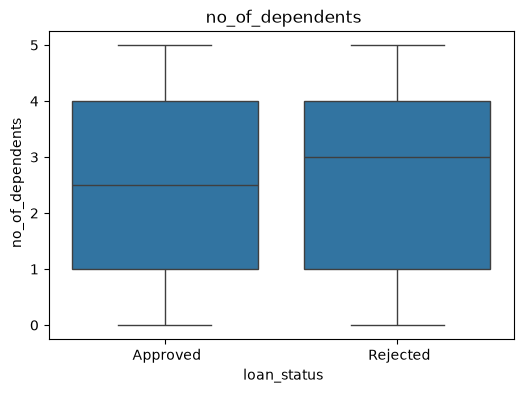

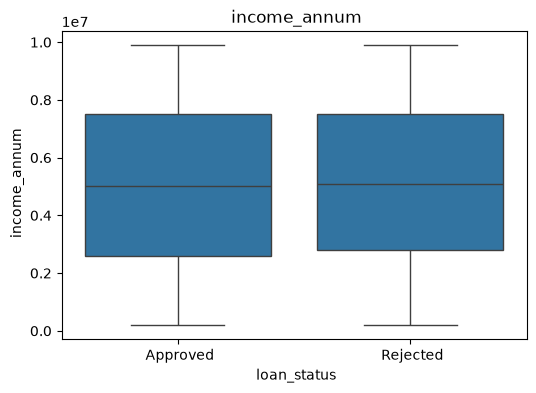

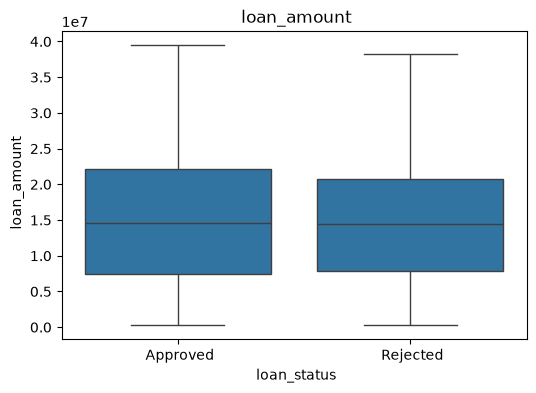

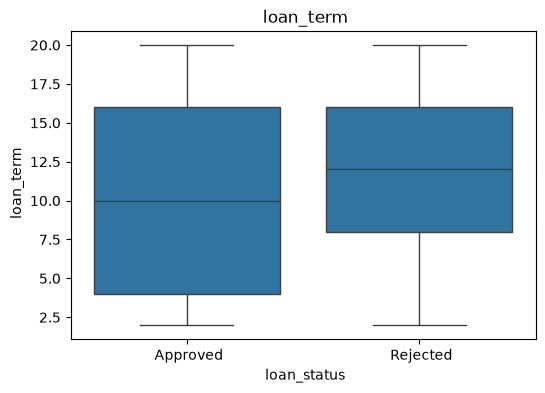

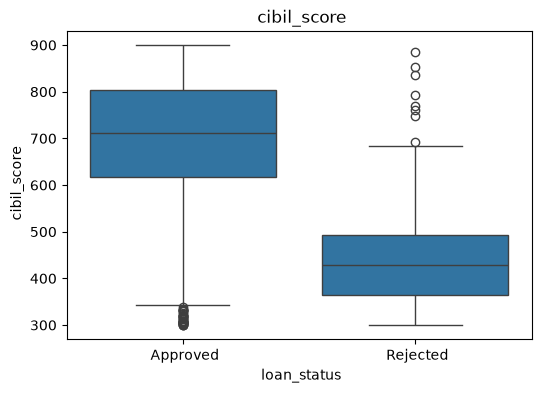

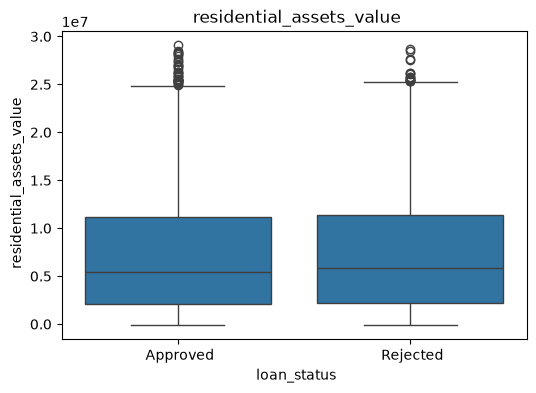

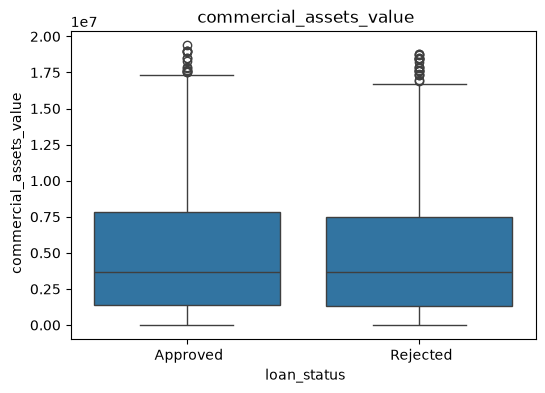

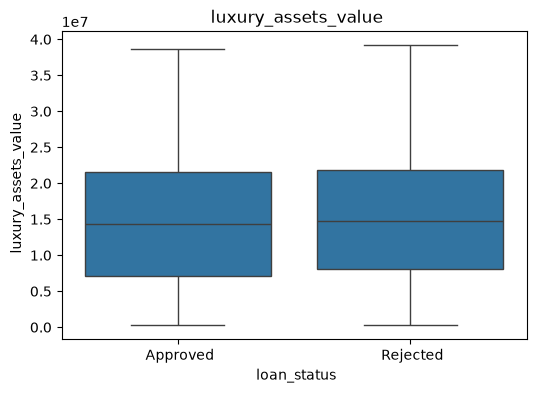

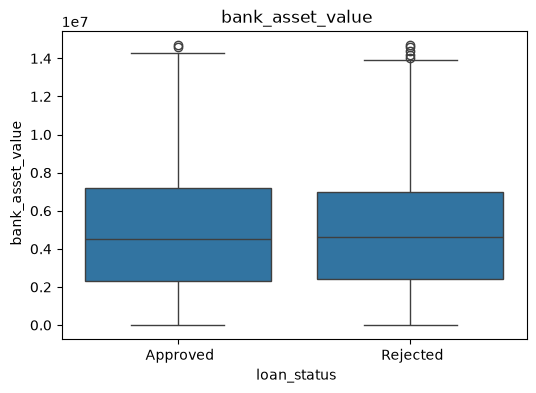

In [53]:
num_cols = df.select_dtypes(include="number").columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x=" loan_status", y=col)
    plt.title(col)
    plt.show()

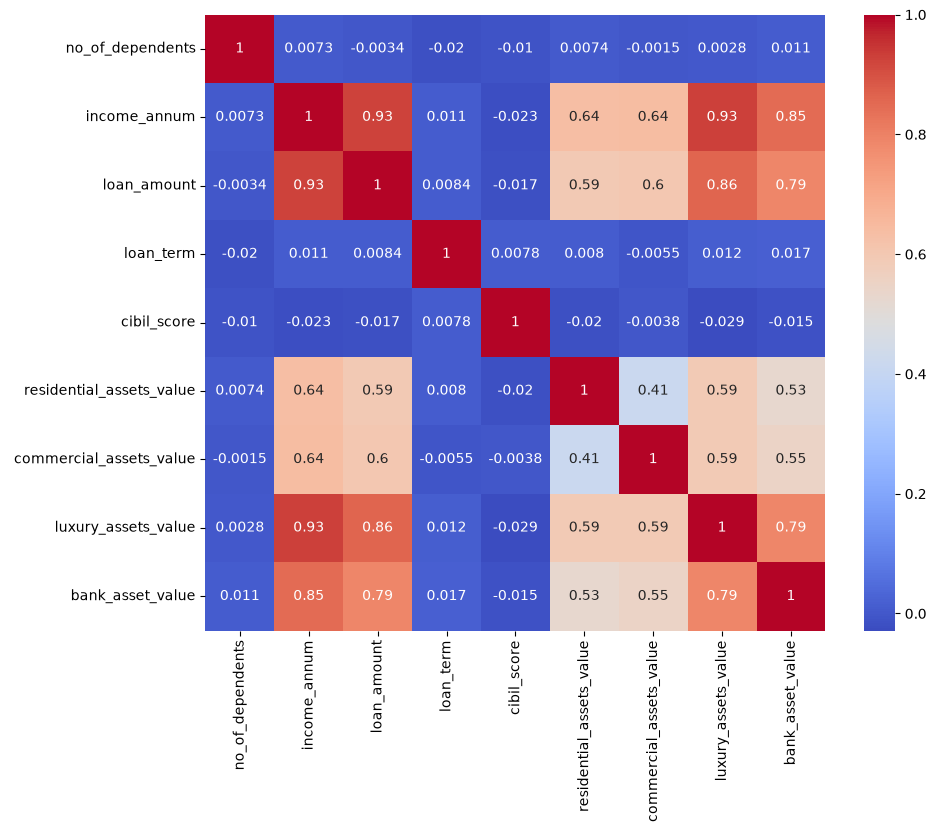

In [54]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [55]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df[" education"] = le.fit_transform(df[" education"])
df[" self_employed"] = le.fit_transform(df[" self_employed"])
df[" loan_status"] = le.fit_transform(df[" loan_status"])

In [56]:
print(df[" education"].unique())
print(df[" self_employed"].unique())
print(df[" loan_status"].unique())

[0 1]
[0 1]
[0 1]


## *Model Building*

### *Logistic Regression*

In [57]:
X = df.drop(" loan_status", axis=1)
y = df[" loan_status"]

In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
from sklearn.preprocessing import StandardScaler    
scaler = StandardScaler()
x_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)
x_train.shape, x_test.shape

((3415, 11), (854, 11))

In [60]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [61]:
y_pred = model.predict(x_test)

### *Model Evaluation*

In [62]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_acc=accuracy_score(y_test, y_pred)

print("Accuracy:", log_acc)
print(classification_report(y_test, y_pred))

Accuracy: 0.905152224824356
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       536
           1       0.88      0.86      0.87       318

    accuracy                           0.91       854
   macro avg       0.90      0.90      0.90       854
weighted avg       0.90      0.91      0.90       854



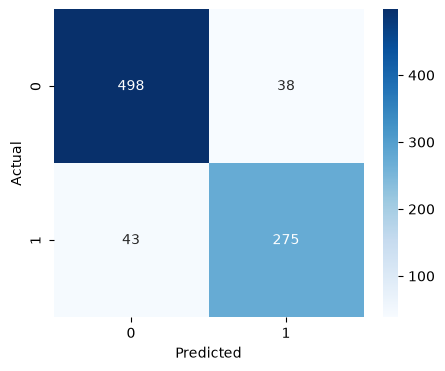

In [63]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### *Decision Tree*

In [64]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)


### *Model Evolution*

Decision Tree
Accuracy: 0.968384074941452
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       536
           1       0.94      0.98      0.96       318

    accuracy                           0.97       854
   macro avg       0.96      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



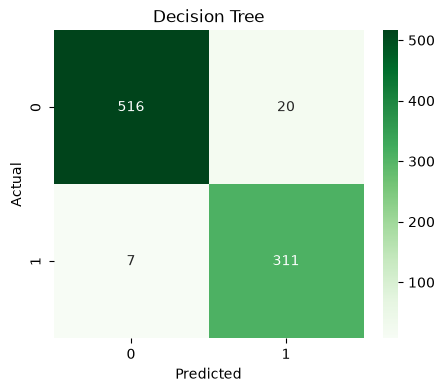

In [65]:
tree_acc = accuracy_score(y_test, tree_pred)

print("="*50)
print("Decision Tree")
print("="*50)
print("Accuracy:", tree_acc)
print(classification_report(y_test, tree_pred))

cm = confusion_matrix(y_test, tree_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### *Random Forest*

In [66]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

In [67]:
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

### *Model Evalution*

Random Forest
Accuracy: 0.9754098360655737
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       536
           1       0.98      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.97       854
weighted avg       0.98      0.98      0.98       854



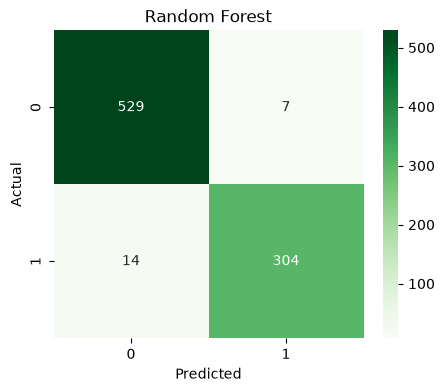

In [68]:
rf_acc = accuracy_score(y_test, rf_pred)

print("="*50)
print("Random Forest")
print("="*50)
print("Accuracy:", rf_acc)
print(classification_report(y_test, rf_pred))

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### *XGBoost*

In [69]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

In [70]:
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

### *Model Evalution*

XGBoost
--------------------------------------------------
Accuracy: 0.9765807962529274
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       536
           1       0.97      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.97       854
weighted avg       0.98      0.98      0.98       854



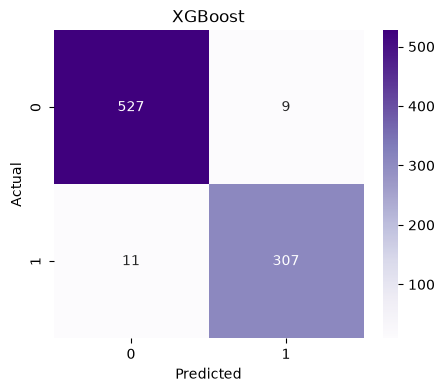

In [71]:
print("XGBoost")
print("-"*50)
xgb_acc = accuracy_score(y_test, xgb_pred)
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.title("XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### *Compare Models*

In [72]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        log_acc,
        tree_acc,
        rf_acc,
        xgb_acc
    ]
})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

print(comparison)

                 Model  Accuracy
3              XGBoost  0.976581
2        Random Forest  0.975410
1        Decision Tree  0.968384
0  Logistic Regression  0.905152


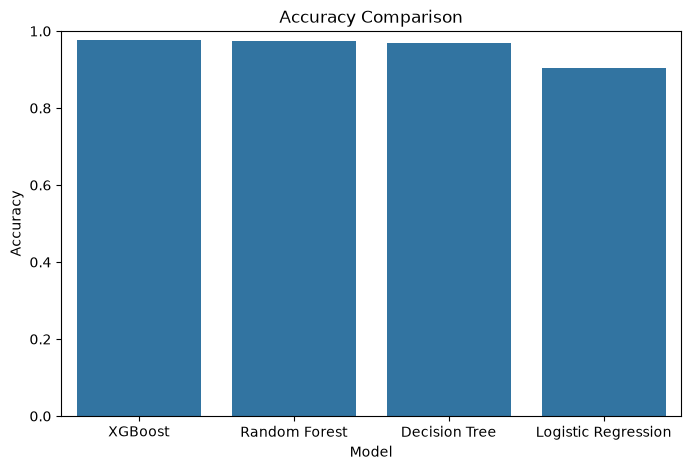

In [73]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.ylim(0,1)
plt.title("Accuracy Comparison")
plt.show()

### *Save Best Model*

In [74]:
import joblib


models = {
    "Logistic Regression": model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

accuracies = {
    "Logistic Regression": log_acc,
    "Decision Tree": tree_acc,
    "Random Forest": rf_acc,
    "XGBoost": xgb_acc
}

best_model_name = max(accuracies, key=accuracies.get)
best_model = models[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"Accuracy: {accuracies[best_model_name]:.4f}")

joblib.dump(best_model, "loan_model.pkl")
joblib.dump(best_model_name, "model_name.pkl")

if best_model_name == "Logistic Regression":
    joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully")

Best Model: XGBoost
Accuracy: 0.9766
Model Saved Successfully


In [75]:
import joblib
import os

loaded_model = joblib.load("loan_model.pkl")
model_name = joblib.load("model_name.pkl")

if model_name == "Logistic Regression":
    scaler = joblib.load("scaler.pkl")

In [76]:
print(X.columns)

Index([' no_of_dependents', ' education', ' self_employed', ' income_annum',
       ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value'],
      dtype='str')



## Example for Testing

### Test Case 1

- **Number of Dependents:** 5
- **Education (Graduate=0, Not Graduate=1):** 1
- **Self Employed (No=0, Yes=1):** 1
- **Annual Income:** 1200000
- **Loan Amount:** 15000000
- **Loan Term:** 20
- **CIBIL Score:** 420
- **Residential Assets Value:** 500000
- **Commercial Assets Value:** 0
- **Luxury Assets Value:** 200000
- **Bank Asset Value:** 100000

**Expected Output:**  Loan Rejected

---

### Test Case 2

- **Number of Dependents:** 2
- **Education (Graduate=0, Not Graduate=1):** 0
- **Self Employed (No=0, Yes=1):** 0
- **Annual Income:** 7500000
- **Loan Amount:** 12000000
- **Loan Term:** 15
- **CIBIL Score:** 780
- **Residential Assets Value:** 8000000
- **Commercial Assets Value:** 2000000
- **Luxury Assets Value:** 10000000
- **Bank Asset Value:** 6000000

**Expected Output:**  Loan Approved

In [77]:
no_of_dependents = int(input("Number of Dependents: "))
education = int(input("Education (Graduate=0, Not Graduate=1): "))
self_employed = int(input("Self Employed (No=0, Yes=1): "))
income_annum = int(input("Annual Income: "))
loan_amount = int(input("Loan Amount: "))
loan_term = int(input("Loan Term: "))
cibil_score = int(input("CIBIL Score: "))
residential_assets_value = int(input("Residential Assets Value: "))
commercial_assets_value = int(input("Commercial Assets Value: "))
luxury_assets_value = int(input("Luxury Assets Value: "))
bank_asset_value = int(input("Bank Asset Value: "))

new_data = [[
    no_of_dependents,
    education,
    self_employed,
    income_annum,
    loan_amount,
    loan_term,
    cibil_score,
    residential_assets_value,
    commercial_assets_value,
    luxury_assets_value,
    bank_asset_value
]]

if model_name == "Logistic Regression":
    new_data = scaler.transform(new_data)

prediction = loaded_model.predict(new_data)
print("Using Model:", model_name)

if prediction[0] == 0:
    print("Loan Approved ")
else:
    print("Loan Rejected ")

Using Model: XGBoost
Loan Approved 
